## 引言

## 研究内容

1）根据研报公式，计算对应的6个因子值，这里采用了和研报同样的参数

2）因子特征的描述，包括因子百分位数走势和因子分布一览 log_market_cap

3）实证分析，沪深A股因子选股分档表现

样本范围：沪深A股历史成分股

实证区间：2025年1月1日至2025年12月12日

选股范围：中证500历史成分股，剔除上市不满一年的股票、剔除ST股票、剔除*ST股票、剔除交易日停牌的股票

分档方式：根据上述的三个因子分别分档，从小到大分5档

调仓周期： 周频换仓（hold_period=5个交易日），Q1档为因子值最小的，Q5档为因子值最大的

参数说明：N=48，n=5，freq=5，hold_period=5

4）因子IC表现，单因子在中证500内选股的IC表现，IC走势和平滑12期IC走势，以及IC的年度表现

5）因子选股多-空策略，RSkew因子在股票池成分股中选股多-空策略净值走势一览以及年度表现

6）因子选股多-基准策略净值走势表现一览，以及多头-基准策略分年度表现一览，多头股票池选股换手率分年度表现一览


## 1.导入一些库

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

## 2.数据的读取与准备

In [2]:
#读取本地数据
market_cap = pd.read_csv('hs_market_cap.csv', index_col='date', parse_dates=True)
open_ = pd.read_csv('hs_price_open.csv', index_col='date', parse_dates=True)

In [9]:
market_cap.index = pd.to_datetime(market_cap.index)
open_.index = pd.to_datetime(open_.index)
market_cap = market_cap.apply(pd.to_numeric, errors='coerce')
open_ = open_.apply(pd.to_numeric, errors='coerce')
log_market_cap = np.log(market_cap)

In [19]:
market_cap.dropna(axis=1, how='all', inplace=True)
market_cap.dropna(axis=1, how='all', inplace=True)
open_.dropna(axis=0, how='all', inplace=True)
open_.dropna(axis=1, how='all', inplace=True)
#1-1计算出1-2买，future_ret1是1-3/1-2的收益率
future_ret1 = open_.pct_change(1).shift(-1-1) #开盘买入以及调仓，因此以开盘价计算1日未来收益率，后续用于计算分组净值
future_ret5 = open_.pct_change(5).shift(-5-1) #同上，5日未来收益率，用于计算后续的IC

In [22]:
log_market_cap.head()

,600000.SH,600004.SH,600006.SH,600007.SH,600008.SH,600009.SH,600010.SH,600011.SH,600012.SH,600015.SH,...,688727.SH,688759.SH,688765.SH,688783.SH,688795.SH,688796.SH,001233.SZ,001280.SZ,001386.SZ,301638.SZ
date,,,,,,,,,,,,,,,,,,,,,
2025-01-02,7.997453,5.399466,5.002603,5.495781,5.449736,6.720115,6.711533,6.803017,5.484282,7.117536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03,7.990519,5.386548,4.927254,5.481625,5.437037,6.713791,6.694819,6.804842,5.494156,7.105855,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-06,7.999426,5.389793,4.919981,5.482045,5.446576,6.713791,6.705993,6.802356,5.477198,7.107159,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-07,8.011179,5.382205,4.947340,5.467267,5.440227,6.711068,6.722522,6.797330,5.461672,7.108462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-08,8.014096,5.380027,4.924351,5.464712,5.433837,6.707122,6.705993,6.795386,5.493628,7.108462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def print_table(table, name=None):
    """
    将 dataframe 表格更好看地输出

    参数：
    ----------
    table : pd.Series or pd.DataFrame
        用于输出的表格.
    name : str, optional
        表格左上的名.
    """
    if isinstance(table, pd.Series):
        table = pd.DataFrame(table)

    if isinstance(table, pd.DataFrame):
        table.columns.name = name

    prev_option = pd.get_option('display.float_format')

    display(table)
                     

## 3.因子的计算和调整

In [24]:
t0 = time.time()
print('因子计算开始')
# RDVar = minute_return.pow(2).groupby(level=0).sum(axis=0) 
# #使用日内数据计算当日收益率的好方法,多重index,groupby(level=0)
# #二维数组，sum(axis=0) 会按列求和,groupby(level=0)计算完成后第二个index就消失了，只留date作为index
# RDSkew = (np.sqrt(N) * minute_return.pow(3).groupby(level=0).sum(axis=0)) / RDVar.pow(3/2)
# RDKurt = N * minute_return.pow(4).groupby(level=0).sum(axis=0) / RDVar.pow(2)
#mad法去极值处理的矩阵运算，将大于/小于 md +/- 3 * mad的部分按大小排序拉回[md+3*mad,md+3.5*mad]/[md-3.5*mad,md-3*mad]区间
def winsorize(df, nsigma=3):
    md = df.median(axis=1)
    mad = 1.483 * (df.sub(md, axis=0)).abs().median(axis=1)
    up = df.apply(lambda k: k > md + mad * nsigma)
    down = df.apply(lambda k: k < md - mad * nsigma)
    df[up] = df[up].rank(axis=1, pct=True).multiply(mad * 0.5, axis=0).add(md + mad * nsigma, axis=0)

    df[down] = df[down].rank(axis=1, pct=True).multiply(mad * 0.5, axis=0).add(md - mad * (0.5 + nsigma), axis=0)

    return df
log_market_cap = winsorize(log_market_cap)
# RDSkew = winsorize(RDSkew)                          
# RDKurt = winsorize(RDKurt)  
# RVol = np.sqrt(RDVar.rolling(n+1).mean() * 242)  #根据研报计算，平滑用了前五天和当日的值，因此rolling窗口期用n+1
# RSkew = RDSkew.rolling(n+1).mean()
# RKurt = RDKurt.rolling(n+1).mean()   
#对研报中的条件进行股票剔除，并去掉所有股票都没有因子值的日期
#df1_log = df1_log[out]
# RDSkew = RDSkew[out]
# RDKurt = RDKurt[out]
# RVol = RVol[out]
# RSkew = RSkew[out]
# RKurt = RKurt[out]
#axis=0上下：沿着行（rows）的方向跨列,axis=1左右：沿着列（cols）的方向跨行
#how='all'：定义删除条件。当且仅当一行中的所有值均为缺失值
#inplace=True：表示直接在原始 DataFrame RDVar 上进行修改
log_market_cap.dropna(axis=0,how='all',inplace=True)
# RDSkew.dropna(axis=0,how='all',inplace=True)
# RDKurt.dropna(axis=0,how='all',inplace=True)
# RVol.dropna(axis=0,how='all',inplace=True)
# RSkew.dropna(axis=0,how='all',inplace=True)
# RKurt.dropna(axis=0,how='all',inplace=True)
t1 = time.time()
print('因子计算完成 耗时 %s 分钟' %round(((t1-t0)/60),3))

因子计算开始
因子计算完成 耗时 0.048 分钟


## 4.中证500因子特征

因子特征报告生成开始
因子特征报告生成完成 耗时 5.729 秒


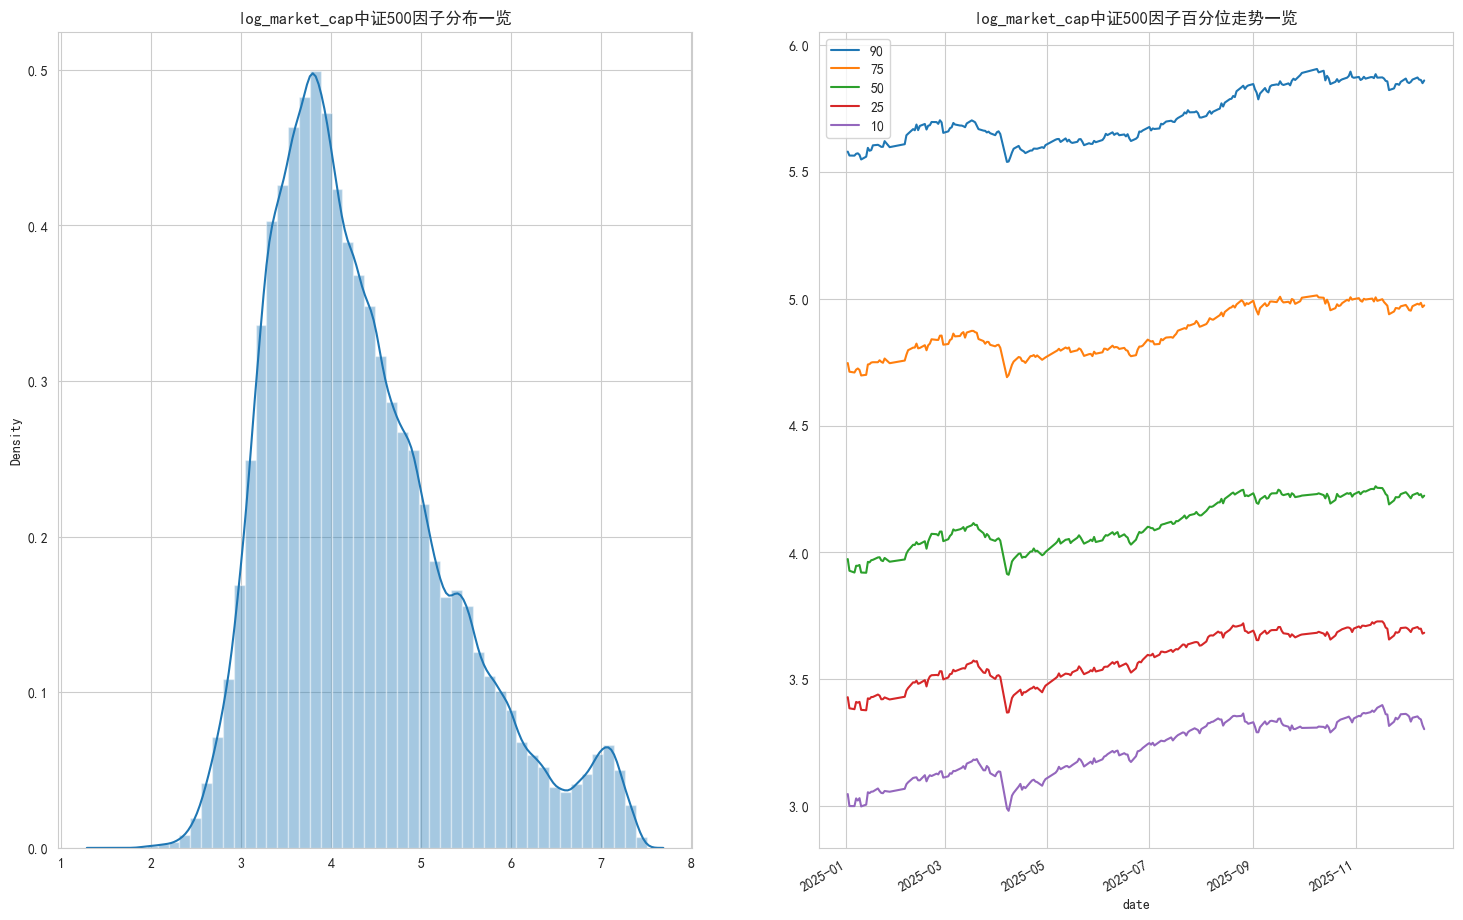

In [25]:
t0 = time.time()
print('因子特征报告生成开始')
def create_characteristic(factor, fac_name): 
    """
    创建因子特征报告，包括因子分布一览和百分位走势一览

    参数：
    ----------
    factor : pd.DataFrame
        用于计算特征的因子.
    fac_name : str,
        因子名，用于绘图时的标题.
    """
    fig,axes = plt.subplots(figsize=(18,12),ncols=2,nrows=1)
    quantile = pd.DataFrame()
    quantiles = [90,75,50,25,10]
    for q in quantiles:
        #axis=1左右，每个date都取前q个
        quantile[q] = factor.quantile(q/100,axis=1)
    quantile.plot(ax=axes[1])
    axes[1].set_title(fac_name + '中证500因子百分位走势一览')
    sns.distplot(factor.stack(),ax=axes[0])
    axes[0].set_title(fac_name + '中证500因子分布一览')
    return axes

create_characteristic(factor=log_market_cap, fac_name='log_market_cap')
# create_characteristic(factor=RSkew, fac_name='RSkew')
# create_characteristic(factor=RKurt, fac_name='RKurt')
t1 = time.time()
print('因子特征报告生成完成 耗时 %s 秒' %round((t1-t0),3))

## 5.中证500因子选股分档表现

因子选股分档表现报告开始
因子选股分档表现报告完成 耗时 0.521 秒


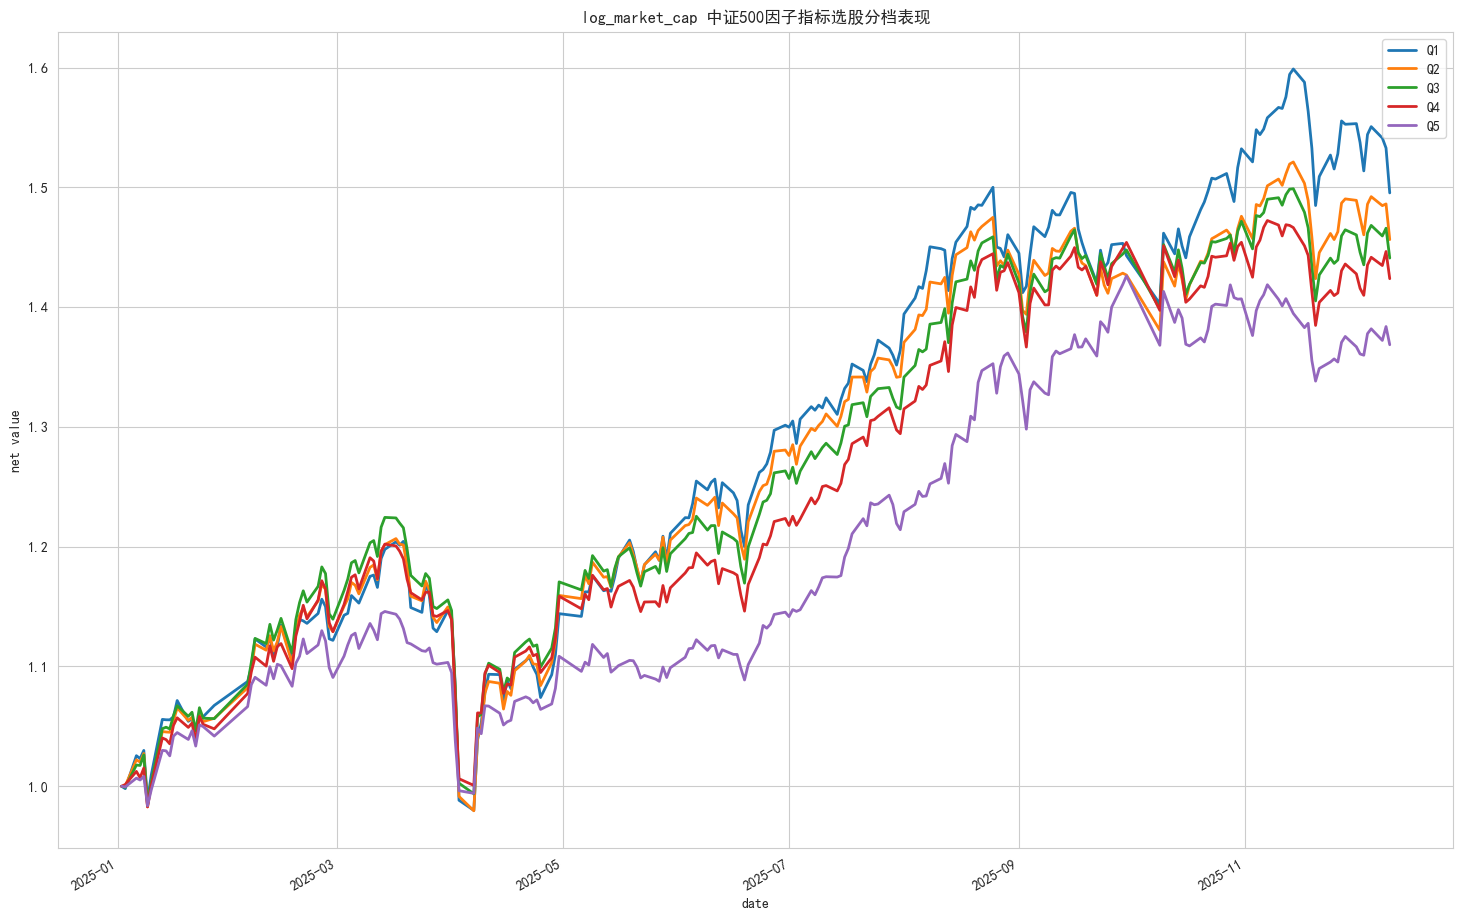

In [27]:
t0 = time.time()
print('因子选股分档表现报告开始')
groups = 5
# groups 分档的组数; hold_period 持仓期（调仓周期）
hold_period = 5
def create_groupret_report(factor,groups,hold_period,fac_name):
    """
    创建因子选股分档报告，因子分档的净值走势

    参数：
    ----------
    factor : pd.DataFrame
        用于计算的因子.
    groups : int
        分档的组数
    hold_period : int
        持仓期（调仓周期）
    fac_name : str,
        因子名，用于绘图时的标题.
    """
    """
    #在pandas中，factor.rank(axis=1, pct=True) 计算每行（因为 axis=1 表示按列方向）的百分比排名，
    而 * 5 // 1 则将这些排名乘以5并取整。具体来说，pct=True 会使排名值变为0到1之间的浮点数，表示该值在行中的相对位置
    （    如0.8表示高于80%的值），然后乘以5将其缩放到0到5的范围，最后 // 1 会将结果转换为整数（即向下取整到最接近的整数）。
    这种操作常用于将排名标准化为固定区间，例如在数据归一化或创建等级指标时。
    例如，如果某行数据的排名百分比为0.6，乘以5后得到3.0，取整后为3。
    """
    grouped = factor.rank(axis=1,pct=True) * groups // 1  #因子分层，得到一个dataframe格式的分层值1-5
    period_group = pd.DataFrame()
    #这里取出每隔调仓期日期的分组情况并重复5次，因为调仓后在下一次调仓前各组持有的股票是不变的
    #::5 是一个切片操作，表示从开始到结束，步长为5。.iloc[::5, :] 会选取DataFrame中每隔4行的完整行（包括所有列），形成一个新的DataFrame。
    to_append = grouped.iloc[::hold_period,:]
    for i in range(5):
        #append已被弃用,使用concat合并进period_group
        #period_group = period_group.append(to_append)
        period_group = pd.concat([period_group, to_append], ignore_index=True)
    #上面重复了5次，日期(1-10)*5，所以需排序
    period_group = period_group.sort_index().iloc[:factor.shape[0],:]
    period_group.index = factor.index[:period_group.shape[0]]  #把index调整回来
    #用于重新索引period_group对象，使其索引与factor对象的索引对齐
    period_group = period_group.reindex_like(factor)
    #计算分组收益率
    group_rets = {}
    for i in range(5):
        #period_group == i，排在第i层的，当期为true,否则false,axis左右运算
        group_rets[i] = future_ret1[period_group == i].mean(axis=1)
    #orient='columns' 指定字典的键（keys）作为新 DataFrame 的列名（columns）
    group_ret = pd.DataFrame.from_dict(group_rets,'columns')
    group_ret.dropna(axis=0,how='all',inplace=True)
    #在起点对齐，计算净值
    group_ret.iloc[0,:] = 0
    net_value = (group_ret + 1).cumprod()
    net_value.columns = ['Q1','Q2','Q3','Q4','Q5']
    fig,ax = plt.subplots(figsize=(18,12))
    net_value.plot(ax=ax,lw=2)
    ax.set_title(fac_name + ' 中证500因子指标选股分档表现')
    ax.set_xlabel('date')
    ax.set_ylabel('net value')
    return ax

create_groupret_report(factor=log_market_cap, groups=groups, hold_period=hold_period, fac_name='log_market_cap')
# create_groupret_report(factor=RSkew, groups=groups, hold_period=hold_period, fac_name='RSkew')
# create_groupret_report(factor=RKurt, groups=groups, hold_period=hold_period, fac_name='RKurt')
t1 = time.time()
print('因子选股分档表现报告完成 耗时 %s 秒' %round((t1-t0),3))

## 6.实证分析 中证500选股 IC部分

IC分析开始


log_market_cap因子中证500选股-IC表现,IC均值,IC标准差,IC最大值,IC最小值,负IC占比
IC,-0.043768,0.108395,0.272218,-0.329673,0.678571


log_market_cap因子中证500选股-IC分年度表现一览,IC均值,IC标准差,IC最大值,IC最小值,负IC占比
year,,,,,
2025,-0.043768,0.108395,0.272218,-0.329673,0.678571
整体,-0.043768,0.108395,0.272218,-0.329673,0.678571


IC分析完成 耗时 0.173 秒


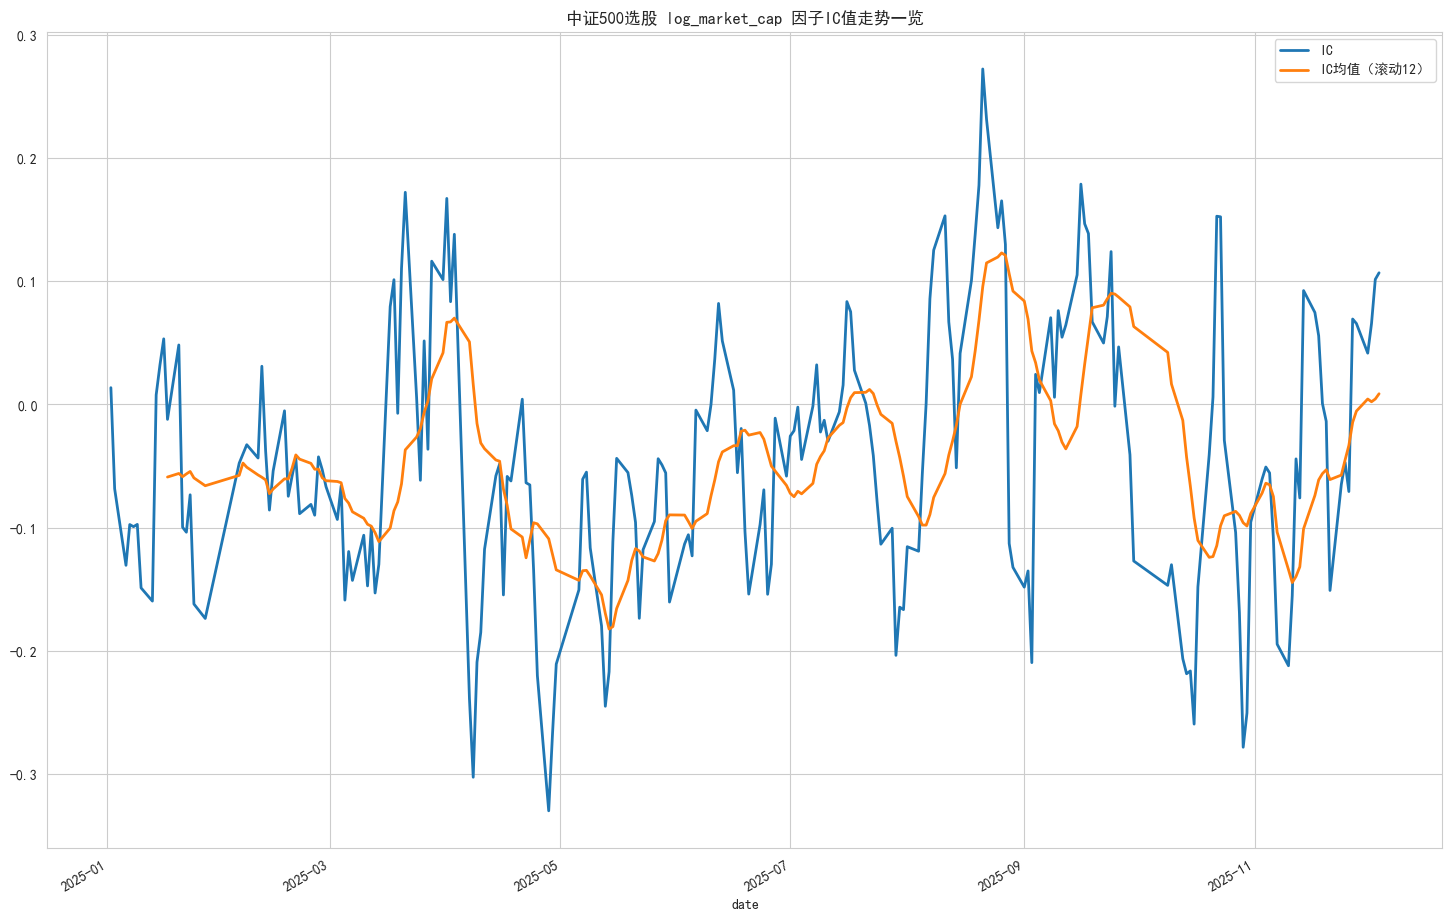

In [29]:
def minus_p(sr):    #计算负值比例
    return sr[sr < 0].count() / sr.count()

def create_ic_report(factor,future_ret,fac_name):
    """
    创建因子IC报告，包括IC统计量和IC走势图

    参数：
    ----------
    factor : pd.DataFrame
        用于计算的因子.
    future_ret : pd.DataFrame
        用于计算IC的未来收益率，这里选用了5日未来收益率，计算5日IC值
    fac_name : str,
        因子名，用于绘图时的标题.
    """
    #计算IC无需分层，只用两个df:factor和return
    #axis左右，同一时间点，做截面所有股票的相关性
    ic = factor.corrwith(future_ret,axis=1)
    #ic是一个 Series，索引是日期，每个值代表该日期横截面上因子值与未来收益率的相关系数
    ic.name = 'IC'
    #series转为dataframe单列的
    ic = ic.to_frame()
    ic_statistic = ic.agg(['mean','std','max','min',minus_p]).T
    ic_statistic.columns = ['IC均值','IC标准差','IC最大值','IC最小值','负IC占比']
    name1 = fac_name + '因子中证500选股-IC表现'
    print_table(ic_statistic,name=name1)

    ic['IC均值（滚动12）'] = ic['IC'].rolling(12).mean()
    fig,ax = plt.subplots(figsize=(18,12))
    #在创建的坐标轴上绘制IC序列的折线图，线宽为2
    ic.plot(ax=ax,lw=2)
    ax.set_title('中证500选股 ' + fac_name + ' 因子IC值走势一览')
    #按年度的IC统计量
    ic['year'] = ic.index.year
    ic.set_index('year',inplace=True)
    ic_sta_byyear = ic['IC'].groupby('year').agg(['mean','std','max','min',minus_p])
    ic_sta_byyear.columns = ['IC均值','IC标准差','IC最大值','IC最小值','负IC占比']
    #这一句的赋值
    ic_sta_byyear.loc['整体',:] = ic_statistic.values
    name2 = fac_name + '因子中证500选股-IC分年度表现一览'
    print_table(ic_sta_byyear,name=name2)

t0 = time.time()
print('IC分析开始')
create_ic_report(factor=log_market_cap, future_ret=future_ret5, fac_name='log_market_cap')
t1 = time.time()
print('IC分析完成 耗时 %s 秒' %round((t1-t0),3))

## 7. 实证分析 中证500选股 多-空策略部分（根据研报，这里仅体现RSkew因子的部分）

多-空策略部分报告开始


中证500成分股log_market_cap因子选股多-空策略分年度表现,累计收益率,最大回撤率,年化收益率,年化波动率,信息比率
year,,,,,
2025,9.28%,12.80%,10.31%,15.62%,0.660142
整体,9.28%,12.80%,10.31%,15.62%,0.660142


多-空策略部分报告完成 耗时 0.466 秒


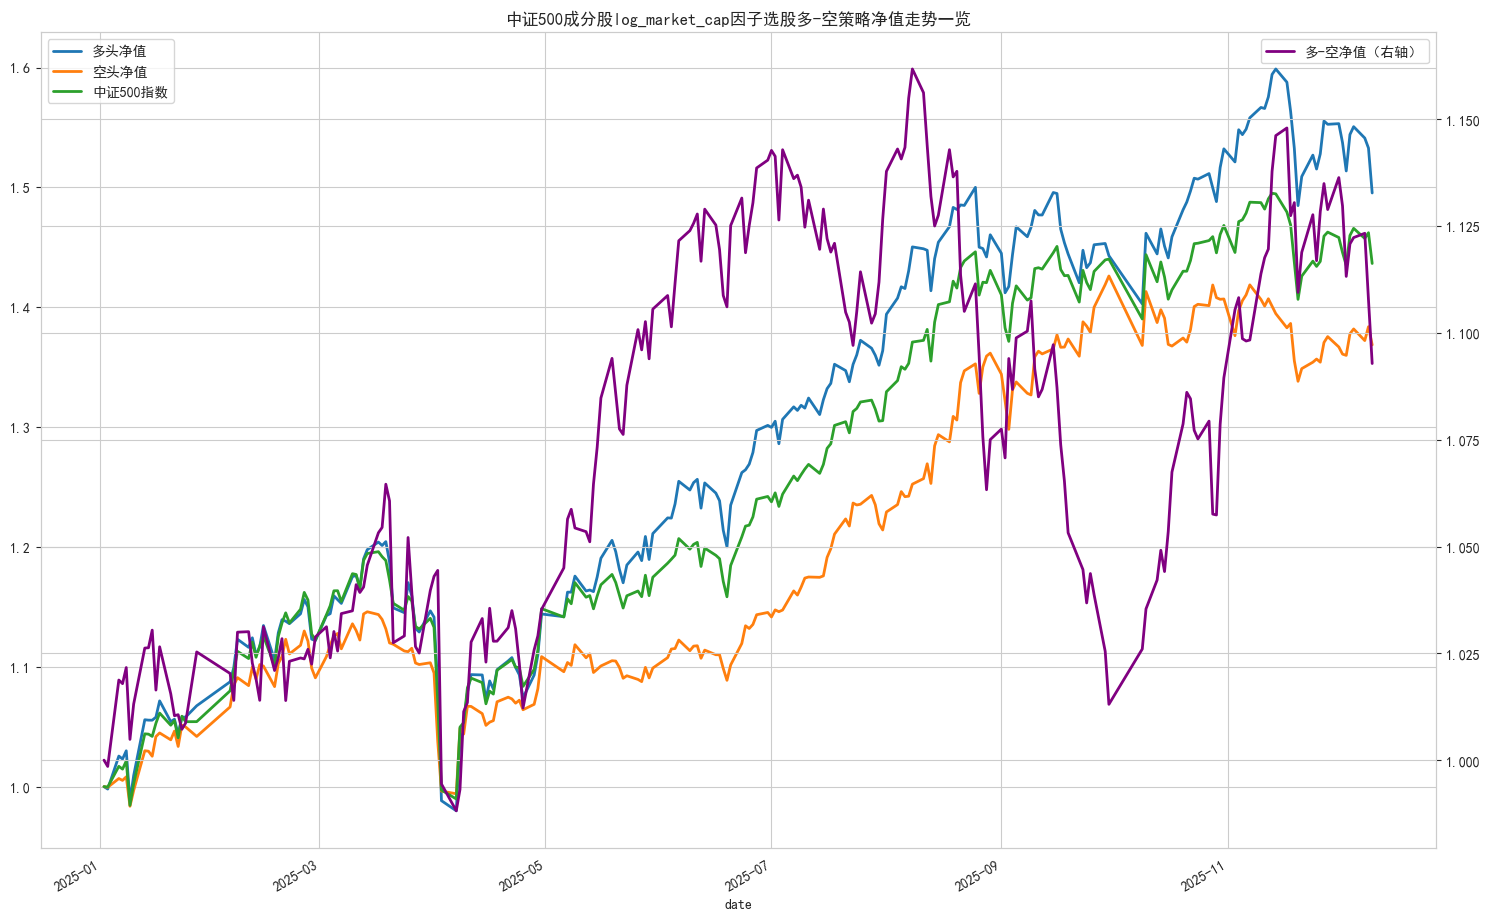

In [31]:
t0 = time.time()
factor = log_market_cap.copy()
fac_name = 'log_market_cap'
hold_period = 5
print('多-空策略部分报告开始')
#sr-净值序列,ret-日收益率序列
def back(sr):   #计算最大回撤率
    return format((1 - sr / sr.cummax()).max(),'.2%')
def cum_ret(sr):    #计算累计收益率
    return format((sr.iloc[-1] - sr.iloc[0]) / sr.iloc[0],'.2%')
def annual_std(ret):    #计算年化波动率
    return (ret.std() * np.sqrt(252))
def annual_ret(sr):     #计算年化收益率
    return ((sr.iloc[-1]/sr.iloc[0])**(252/len(sr)) - 1)

#以下和上面分档部分的计算相同
grouped = factor.rank(axis=1,pct=True) * groups // 1
period_group = pd.DataFrame()
to_append = grouped.iloc[::hold_period,:]
for i in range(5):
    period_group = pd.concat([period_group, to_append], ignore_index=True)
period_group = period_group.sort_index().iloc[:factor.shape[0],:]
period_group.index = factor.index[:period_group.shape[0]]
period_group = period_group.reindex_like(factor)
group_rets = {}
for i in range(5):
    group_rets[i] = future_ret1[period_group == i].mean(axis=1)
group_ret = pd.DataFrame.from_dict(group_rets,'columns')
group_ret.dropna(axis=0,how='all',inplace=True)
group_ret.iloc[0,:] = 0
net_value = (group_ret + 1).cumprod()
net_value.columns = ['Q1','Q2','Q3','Q4','Q5']
#计算选股池的净值走势    
stock_pool_bench = future_ret1.mean(axis=1).loc[net_value.index]
stock_pool_bench.iloc[0] = 0
stock_pool_bench = (stock_pool_bench + 1).cumprod()
#取出多头 空头 多-空 和中证500的净值    
top_bottom = net_value[['Q1','Q5']]
top_bottom['tb'] = ((group_ret.iloc[:,0] - group_ret.iloc[:,-1]) + 1).cumprod()
top_bottom['bench'] = stock_pool_bench.values
top_bottom.columns = ['多头净值','空头净值','多-空净值（右轴）','中证500指数']
#净值走势绘图，将多-空净值纵坐标绘制于右轴    
fig,ax = plt.subplots(figsize=(18,12))
ax1 = ax.twinx()
top_bottom[['多头净值','空头净值','中证500指数']].plot(ax=ax,lw=2)
top_bottom['多-空净值（右轴）'].plot(ax=ax1,lw=2,legend=True,color='purple')
ax.legend(loc='upper left')
ax1.legend(loc='upper right')
ax.set_title('中证500成分股' + fac_name + '因子选股多-空策略净值走势一览')

tb_ret = (group_rets[0] - group_rets[4]).dropna(how='all')
table_name = '中证500成分股' + fac_name + '因子选股多-空策略分年度表现'
def create_table(to_table_nv,col,ret):
    """
    创建策略年度表现表格，包括累计收益率 最大回撤率 年化收益率 年化波动率 信息比率

    参数：
    ----------
    to_table_nv : pd.DataFrame
        用于计算净值走势df.
    col : str
        净值走势df中的要计算年度表现策略的列名，用于将其取出
    ret : pd.Series
        策略的收益率序列，用于计算年化波动率
    """
    to_table_nv['year'] = to_table_nv.index.year   #调整index用于之后计算年度表现
    byyear = to_table_nv.set_index('year')[col]   #取出传入的净值走势df中需要的列



    ret.index = byyear.index
    ratio_table = byyear.groupby(level=0).agg([cum_ret,back,annual_ret])
    ratio_table['annual_std'] = ret.groupby(level=0).apply(annual_std)
    ratio_table['information rate'] = ratio_table['annual_ret']/ratio_table['annual_std']
    ratio_table['annual_ret'] = ratio_table['annual_ret'].apply(lambda x:format(x,'.2%'))
    ratio_table['annual_std'] = ratio_table['annual_std'].apply(lambda x:format(x,'.2%')) #这里不在之前的函数中输出为百分数主要是为了计算信息比率
    #计算整体的表现
    allyear = byyear.agg([cum_ret,back,annual_ret]).values
    allyear = np.append(allyear,ret.std() * np.sqrt(252))
    allyear = np.append(allyear,allyear[2]/allyear[3])
    allyear[2] = format(allyear[2],'.2%')
    allyear[3] = format(allyear[3],'.2%')
    ratio_table.loc['整体',:] = allyear
    ratio_table.columns = ['累计收益率','最大回撤率','年化收益率','年化波动率','信息比率']
    #print_table(ratio_table,name=table_name)
    return ratio_table
table = create_table(to_table_nv=top_bottom, col='多-空净值（右轴）', ret=tb_ret)
print_table(table, name=table_name)
t1 = time.time()
print('多-空策略部分报告完成 耗时 %s 秒' %round((t1-t0),3))

## 8. 实证分析 中证500选股 因子选股 多-中证500策略部分

多-中证500策略部分报告开始


多头表现                                   多-中证500表现                       \
       累计收益率   最大回撤率   年化收益率   年化波动率      信息比率     累计收益率  最大回撤率  年化收益率  年化波动率   
year                                                                            
2025  49.53%  18.65%  56.00%  24.87%  2.251383     4.39%  5.31%  4.86%  7.69%   
整体    49.53%  18.65%  56.00%  24.87%  2.251383     4.39%  5.31%  4.86%  7.69%   

                
          信息比率  
year            
2025  0.632237  
整体    0.632237

多-中证500策略部分报告完成 耗时 0.144 秒


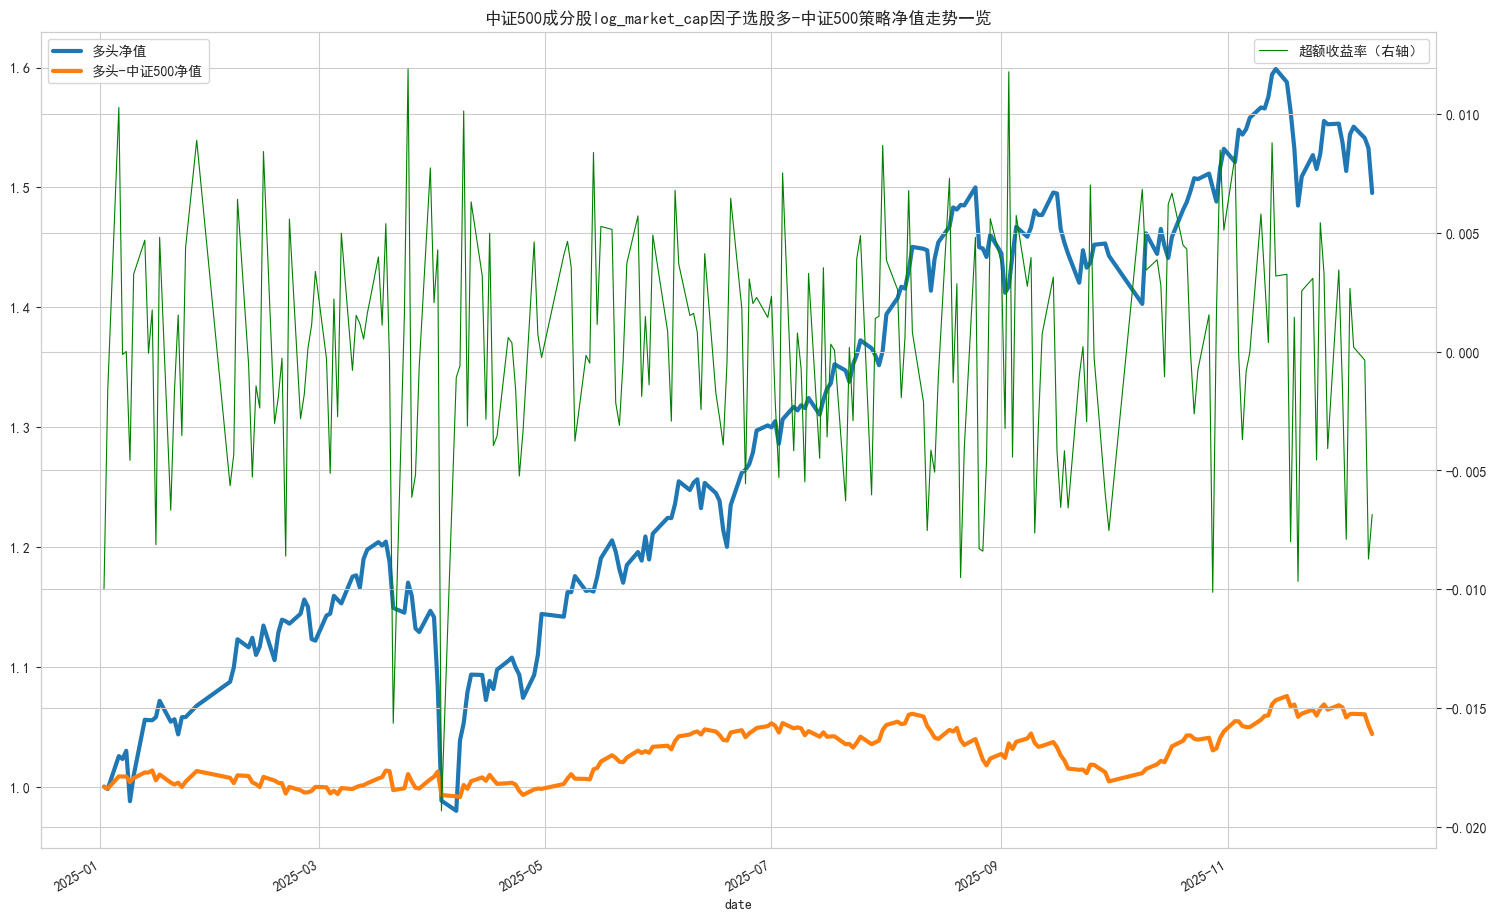

In [32]:
t0 = time.time()
print('多-中证500策略部分报告开始')
#先计算用于绘图和后续表格输出的净值走势df，包括多头净值和多-中证500净值
top = net_value['Q1'].to_frame()   
top_alpha = (group_rets[0] - future_ret1.mean(axis=1).loc[net_value.index]).dropna(how='all')  #多头相对中证500的超额收益率
top['top-bench'] = top_alpha
top['top-bench'].iloc[0] = 0
top['top-bench'] = top['top-bench'].add(1).cumprod()
top.columns = ['多头净值','多头-中证500净值']
top_alpha.name = '超额收益率（右轴）'
#净值和超额收益率绘图，超额收益率纵坐标绘制于右轴
fig,ax = plt.subplots(figsize=(18,12))
ax1 = ax.twinx()
top.plot(ax=ax,lw=3)
top_alpha.plot(ax=ax1,legend=True,color='g',lw=0.8)
ax.legend(loc='upper left')
ax.set_title('中证500成分股' + fac_name + '因子选股多-中证500策略净值走势一览')

top_ret = group_rets[0].dropna()   #多头收益率
table1 = create_table(to_table_nv=top, col='多头净值', ret=top_ret)
#调整一下多头年度策略表格的层次列名
table1.columns = pd.MultiIndex.from_product([['多头表现'],['累计收益率','最大回撤率','年化收益率','年化波动率','信息比率']])

table2 = create_table(to_table_nv=top, col='多头-中证500净值', ret=top_alpha)
#同上
table2.columns = pd.MultiIndex.from_product([['多-中证500表现'],['累计收益率','最大回撤率','年化收益率','年化波动率','信息比率']])
#拼接两个表格并输出
print_table(pd.concat([table1,table2],axis=1))

t1 = time.time()
print('多-中证500策略部分报告完成 耗时 %s 秒' %round((t1-t0),3))

## 9. 实证部分 中证500选股 因子选股 多-中证500策略 换手率部分

In [33]:
t0 = time.time()
print('换手率报告开始')
#这里计算换手率的结果于研报在最小值上有比较大的出入，可能是采用的方式与研报不同
def cal_turnover(grouped, quantile, hold_period):
    """
    创建策略年度换手率分析表格，包括均值 最大值 最小值 标准差 累计值

    参数：
    ----------
    grouped : pd.DataFrame
        因子选股分档后的df，值为某天某股票所在的分组.
    quantile : int
        要计算的组别，根据之前的分层方式，若计算第k组，输入k-1
    hold_period : int
        调仓周期
    """
    #取出每次调仓时选中的所有股票
    quant_name_sets=grouped.iloc[::hold_period].apply(lambda k: set(k[k == quantile].index), axis=1)
    #作差，得到新一次调仓时相对于之前新增的股票
    new_names = (quant_name_sets - quant_name_sets.shift(1)).dropna()
    #新增股票相对于之前持仓股票数的比例即换手率
    #计算每列的长度（行数），返回每一列的行数（通常每列都一样，就是DataFrame的行数）
    quant_turnover = new_names.apply(lambda x: len(x))/\
                    quant_name_sets.apply(lambda x: len(x))
    quant_turnover.name = quantile
    return quant_turnover

def max_turn(sr):  #最大换手率
    return format(sr.max(),'.2%')
def min_turn(sr):  #最小换手率
    return format(sr.min(),'.2%')
def std_turn(sr):  #换手率标准差
    return format(sr.std(),'.2%')
def mean_turn(sr):  #换手率均值
    return format(sr.mean(),'.2%')
def cumsum_turn(sr):  #换手率累计值
    return sr.sum()
top_turnover = cal_turnover(grouped=grouped, quantile=0, hold_period=hold_period).dropna()
top_turnover.index = top_turnover.index.year
turn_table = top_turnover.groupby(level=0).agg([mean_turn,max_turn,min_turn,std_turn,cumsum_turn])
turn_table.loc['整体',:] = top_turnover.agg([mean_turn,max_turn,min_turn,std_turn,cumsum_turn]).values
turn_table.columns = ['均值','最大值','最小值','标准差','累计值']
name = '中证500选股换手率分年度表现'
print_table(turn_table, name=name)
t1 = time.time()
print('换手率报告完成 耗时 %s 秒' %round((t1-t0),3))

换手率报告开始


中证500选股换手率分年度表现,均值,最大值,最小值,标准差,累计值
date,,,,,
2025,3.98%,7.14%,2.73%,0.78%,1.789575
整体,3.98%,7.14%,2.73%,0.78%,1.789575


换手率报告完成 耗时 0.044 秒


In [34]:
t_end = time.time()
print('所有报告生成完成 耗时 %s 分钟' %round(((t_end-t_begin)/60),3))

NameError: name 't_begin' is not defined